# Step 1: Map classical inputs to a quantum problem

In [ ]:
# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Qiskit Runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

In [2]:
controls = QuantumRegister(2, name="control")
target = QuantumRegister(1, name="target")

mid_measure = ClassicalRegister(2, name="mid")
final_measure = ClassicalRegister(1, name="final")

circuit = QuantumCircuit(controls, target, mid_measure, final_measure)

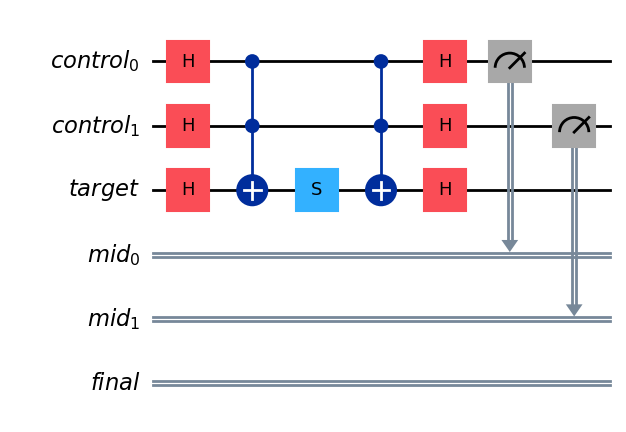

In [4]:
def trial(circuit, target, controls, measures):
    """Probabilistically perform an Rx gate for an
    angle that is an irrational multiple of pi."""
    circuit.h(target)
    circuit.h(controls)
    circuit.ccx(*controls, target)
    circuit.s(target)
    circuit.ccx(*controls, target)
    circuit.h(controls)
    circuit.h(target)
    circuit.measure(controls, measures)

trial(circuit, target, controls, mid_measure)
circuit.draw(output="mpl", style='iqp', cregbundle=False)

In [5]:
def reset_controls(circuit, controls,  measures):
    """Reset the controlling qubits if they are in |1>."""
    with circuit.if_test((measures[0], True)):
        circuit.x(controls[0])
    with circuit.if_test((measures[1], True)):
        circuit.x(controls[1])

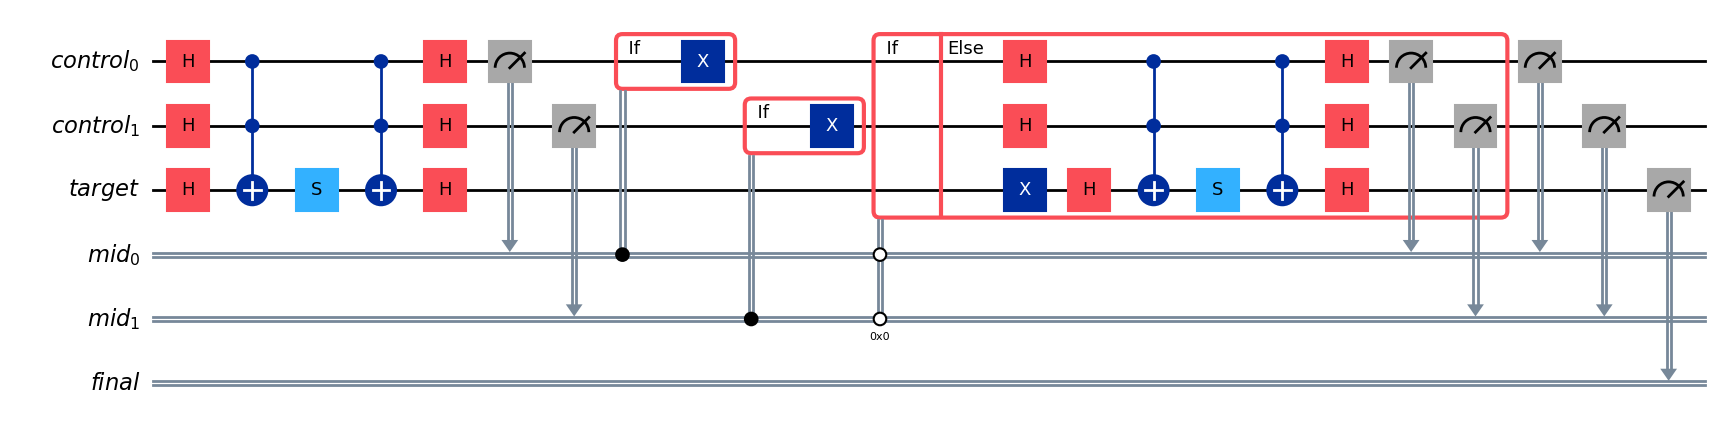

In [6]:
max_trials = 2

# Manually add the rest of the trials.  In the future, you can
# use a dynamic `while` loop to do this, but for now,
# statically add each loop iteration with a manual condition check
# on each one.  This involves more classical synchronizations than
# the while loop, but will suffice for now.
for _ in range(max_trials - 1):
    reset_controls(circuit, controls, mid_measure)
    with circuit.if_test((mid_measure, 0b00)) as else_:
        # This is the success path, but Qiskit can't directly
        # represent a negative condition yet, so we have an
        # empty `true` block in order to use the `else` branch.
        pass
    with else_:
        # First reset the target.
        circuit.x(target)
        # Then repeat the trial.
        trial(circuit, target, controls, mid_measure)

# Measure the control qubits again to ensure you
# get their final results; this is a hardware limitation.
circuit.measure(controls, mid_measure)

# Finally, measure the target, to check that you're
# getting the desired rotation.
circuit.measure(target, final_measure)

circuit.draw(output="mpl", style='iqp', cregbundle=False)

# Step 2. Optimize problem for quantum execution

In [7]:
# To run on hardware, select the backend with the fewest number of jobs in the queue

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f">>> Connected to {backend.name} backend.")

>>> Connected to ibm_sherbrooke backend.


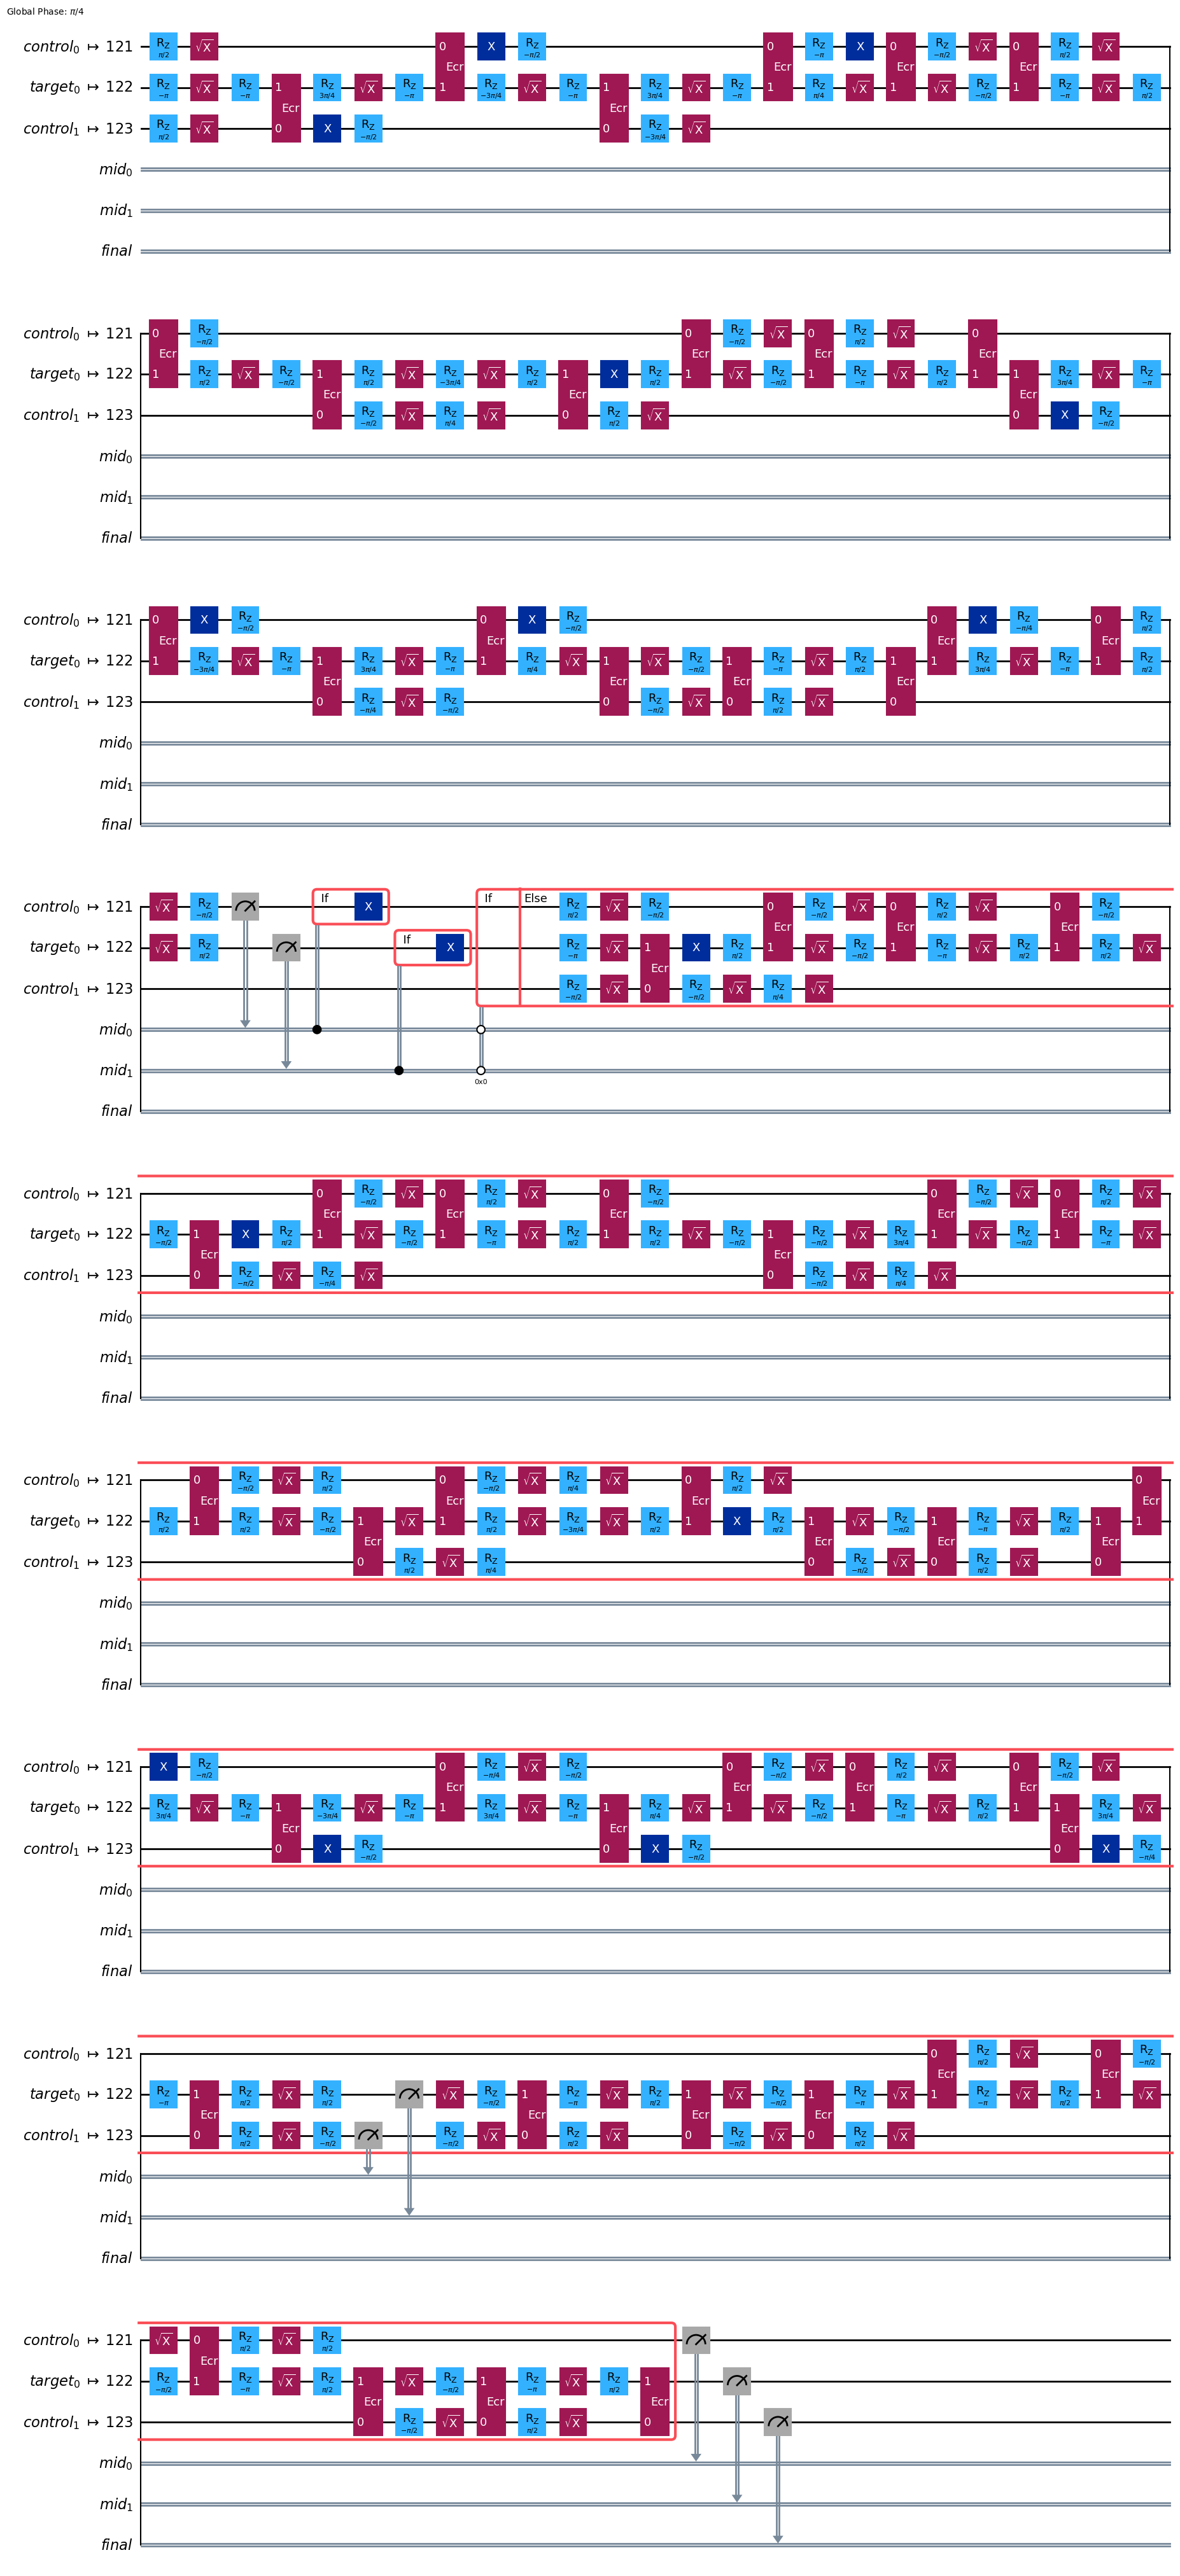

In [8]:
# Circuits must obey the ISA of a particular backend.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

isa_circuit.draw(output="mpl", style='iqp', idle_wires=False, cregbundle=False)

# Step 3. Execute using Qiskit primitives


In [9]:
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
job.job_id()

'd0d1j9sqnmvg0087qh80'

In [11]:
hardware_counts = job.result()[0]

data_mid = job.result()[0].data.mid
data_final = job.result()[0].data.final

print(f">>> Hardware counts for mid: {data_mid.get_counts()}")
print(f">>> Hardware counts for final: {data_final.get_counts()}")

>>> Hardware counts for mid: {'01': 629, '00': 2527, '10': 501, '11': 439}
>>> Hardware counts for final: {'0': 2463, '1': 1633}


In [12]:
from collections import defaultdict

merged_data = defaultdict(int)
for bs1, bs2 in zip(data_mid.get_bitstrings(), data_final.get_bitstrings()):
    merged_data[f"{bs1}-{bs2}"] += 1

print(f">>> Hardware merged data: {dict(merged_data)}")

>>> Hardware merged data: {'01-0': 351, '00-1': 865, '00-0': 1662, '10-0': 245, '11-1': 234, '11-0': 205, '01-1': 278, '10-1': 256}


# Step 4. Post-process, return result in classical format

In [13]:
def marginalize_successes(counts):
    """Split the full output `counts` dictionary
    into two separate dictionaries, marginalizing
    the results to leave only the target qubit's
    state."""
    successes = defaultdict(int)
    failures = defaultdict(int)

    for key, value in counts.items():
        if key.startswith("00"):
            successes[key[-1]] += value
        else:
            failures[key[-1]] += value

    return successes, failures

In [14]:
hw_successes, hw_failures = marginalize_successes(merged_data)

expected_successes = 1 - (1 - 5/8)**max_trials
actual_successes = sum(hw_successes.values()) / sum(merged_data.values())
print(f"Expected success rate {expected_successes:5.3f}.  Actual rate {actual_successes:5.3f}.")

Expected success rate 0.859.  Actual rate 0.617.


In [ ]:
actual_probability = hw_successes["1"] / sum(hw_successes.values())
print(f"Expected |1> probability: 0.2.  Actual probability {actual_probability:5.3f}.")

Expected |1> probability: 0.2.  Actual probability 0.342.


: 